In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

1. Część I

In [32]:
final = pd.read_csv("final.csv.gz")
final["date"] = pd.to_datetime(final["date"])
final.head()

,CTRY_ISO,date,temp,prcp,wdsp,slp,dewp,"Abaca, manila hemp, raw","Agave fibres, raw, n.e.c.","Almonds, in shell",...,"True hemp, raw or retted",Tung nuts,Unmanufactured tobacco,"Vanilla, raw",Vetches,"Walnuts, in shell",Watermelons,Wheat,Yams,Yautia
0,AE,2020-01-01,20.916667,0.0,9.58410,1014.985714,11.180556,NaN,NaN,7857.1,...,NaN,NaN,16000.0,NaN,NaN,NaN,30010.7,NaN,NaN,NaN
1,AE,2020-01-02,21.770833,0.0,8.38030,1018.225000,14.111111,NaN,NaN,7857.1,...,NaN,NaN,16000.0,NaN,NaN,NaN,30010.7,NaN,NaN,NaN
2,AE,2020-01-03,22.416667,0.0,8.21825,1018.575000,12.812500,NaN,NaN,7857.1,...,NaN,NaN,16000.0,NaN,NaN,NaN,30010.7,NaN,NaN,NaN
3,AE,2020-01-04,23.090278,0.0,11.36665,1015.462500,10.527778,NaN,NaN,7857.1,...,NaN,NaN,16000.0,NaN,NaN,NaN,30010.7,NaN,NaN,NaN
4,AE,2020-01-05,23.500000,0.0,17.57085,1012.887500,14.500000,NaN,NaN,7857.1,...,NaN,NaN,16000.0,NaN,NaN,NaN,30010.7,NaN,NaN,NaN


1. 1. Kraj do analizy

In [33]:
country = "PL"

df = final[final["CTRY_ISO"] == country].copy()
df = df.sort_values("date")
df = df.set_index("date")
df

,CTRY_ISO,temp,prcp,wdsp,slp,dewp,"Abaca, manila hemp, raw","Agave fibres, raw, n.e.c.","Almonds, in shell","Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw",...,"True hemp, raw or retted",Tung nuts,Unmanufactured tobacco,"Vanilla, raw",Vetches,"Walnuts, in shell",Watermelons,Wheat,Yams,Yautia
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,PL,1.599156,0.318304,16.527342,1029.564151,-0.928270,NaN,NaN,NaN,NaN,...,6100.0,NaN,2083.7,NaN,NaN,2333.3,NaN,5234.2,NaN,NaN
2020-01-02,PL,0.513032,0.003136,12.522721,1026.203774,-4.318244,NaN,NaN,NaN,NaN,...,6100.0,NaN,2083.7,NaN,NaN,2333.3,NaN,5234.2,NaN,NaN
2020-01-03,PL,1.419067,0.102973,16.089536,1018.729630,-1.770233,NaN,NaN,NaN,NaN,...,6100.0,NaN,2083.7,NaN,NaN,2333.3,NaN,5234.2,NaN,NaN
2020-01-04,PL,2.760197,2.474686,23.670435,1013.675926,0.531646,NaN,NaN,NaN,NaN,...,6100.0,NaN,2083.7,NaN,NaN,2333.3,NaN,5234.2,NaN,NaN
2020-01-05,PL,0.115331,3.403600,16.180385,1027.661111,-2.800281,NaN,NaN,NaN,NaN,...,6100.0,NaN,2083.7,NaN,NaN,2333.3,NaN,5234.2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,PL,2.847051,2.743200,18.572588,1018.792157,-0.426612,NaN,NaN,NaN,NaN,...,3147.7,NaN,2049.5,NaN,NaN,3000.0,31500.0,5280.0,NaN,NaN
2023-12-28,PL,4.570461,0.144585,16.218551,1014.198077,1.388889,NaN,NaN,NaN,NaN,...,3147.7,NaN,2049.5,NaN,NaN,3000.0,31500.0,5280.0,NaN,NaN
2023-12-29,PL,6.684959,0.125211,19.247249,1009.188235,3.237311,NaN,NaN,NaN,NaN,...,3147.7,NaN,2049.5,NaN,NaN,3000.0,31500.0,5280.0,NaN,NaN


1. 2. Ustawiamy okno czasowe

In [34]:
window = 30

1. 3. TEMPERATURA

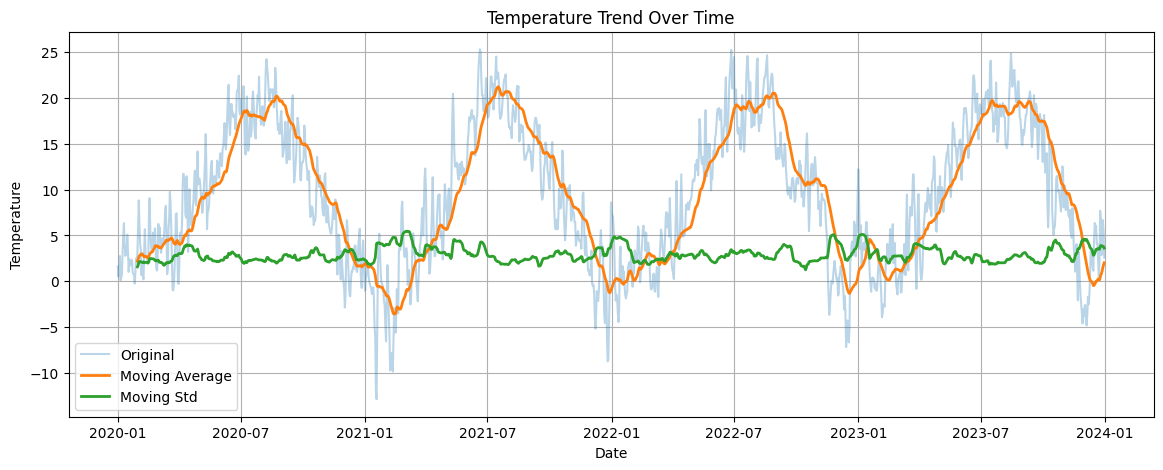

In [35]:
df["temp_ma"] = df["temp"].rolling(window=window).mean()
df["temp_std"] = df["temp"].rolling(window=window).std()

plt.figure(figsize=(14,5))

plt.plot(df.index, df["temp"], alpha=0.3, label="Original")
plt.plot(df.index, df["temp_ma"], linewidth=2, label="Moving Average")
plt.plot(df.index, df["temp_std"], linewidth=2, label="Moving Std")

plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid()
plt.show()

1. 4. OPADY

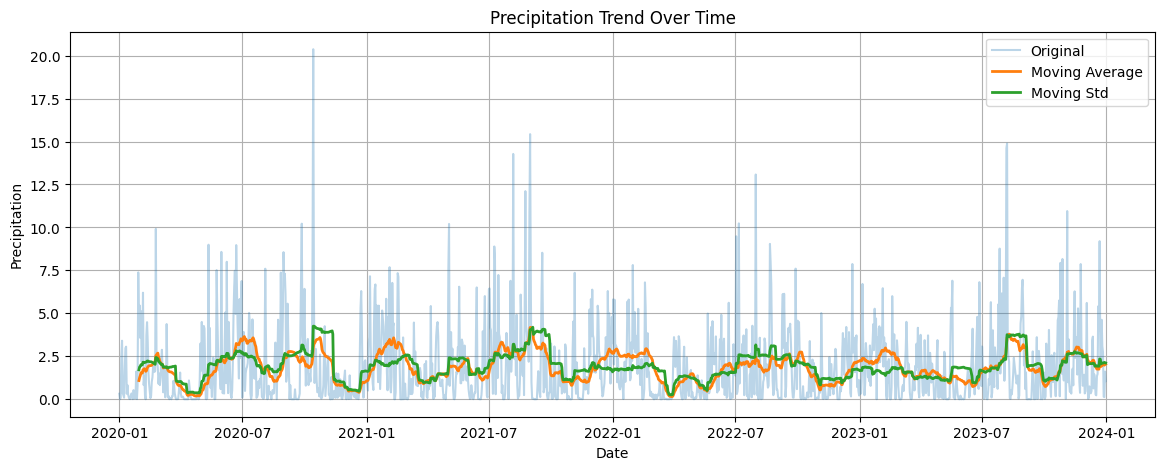

In [36]:
df["prcp_ma"] = df["prcp"].rolling(window=window).mean()
df["prcp_std"] = df["prcp"].rolling(window=window).std()

plt.figure(figsize=(14,5))

plt.plot(df.index, df["prcp"], alpha=0.3, label="Original")
plt.plot(df.index, df["prcp_ma"], linewidth=2, label="Moving Average")
plt.plot(df.index, df["prcp_std"], linewidth=2, label="Moving Std")

plt.title("Precipitation Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.legend()
plt.grid()
plt.show()

1. 5. PRĘDKOŚĆ WIATRU

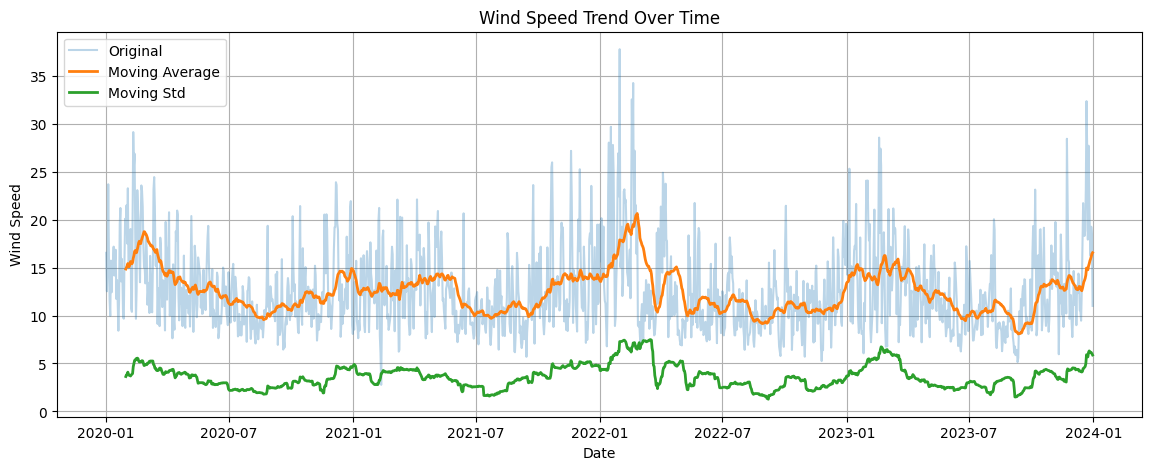

In [37]:
df["wdsp_ma"] = df["wdsp"].rolling(window=window).mean()
df["wdsp_std"] = df["wdsp"].rolling(window=window).std()

plt.figure(figsize=(14,5))

plt.plot(df.index, df["wdsp"], alpha=0.3, label="Original")
plt.plot(df.index, df["wdsp_ma"], linewidth=2, label="Moving Average")
plt.plot(df.index, df["wdsp_std"], linewidth=2, label="Moving Std")

plt.title("Wind Speed Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Wind Speed")
plt.legend()
plt.grid()
plt.show()

1. 6. CIŚNIENIE

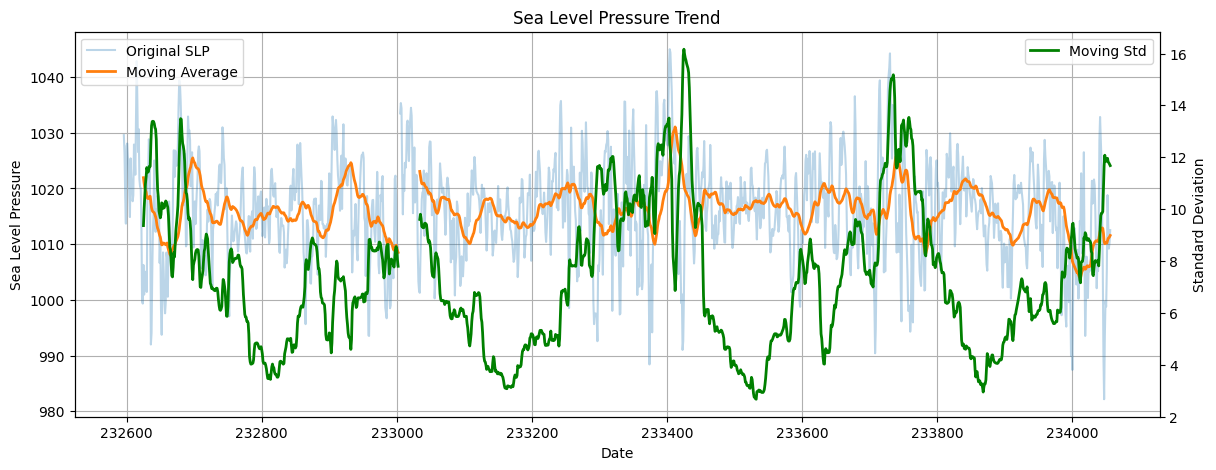

In [58]:
df["slp_ma"] = df["slp"].rolling(window=window).mean()
df["slp_std"] = df["slp"].rolling(window=window).std()

fig, ax1 = plt.subplots(figsize=(14,5))

ax1.plot(df.index, df["slp"], alpha=0.3, label="Original SLP")
ax1.plot(df.index, df["slp_ma"], linewidth=2, label="Moving Average")

ax1.set_ylabel("Sea Level Pressure")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(df.index, df["slp_std"],  linewidth=2, label="Moving Std", color="green")
ax2.set_ylabel("Standard Deviation")

plt.title("Sea Level Pressure Trend")
plt.xlabel("Date")

ax1.grid()
ax1.legend(loc= "upper left")
ax2.legend(loc="upper right")
plt.show()

1. 7. PUNKT ROSY

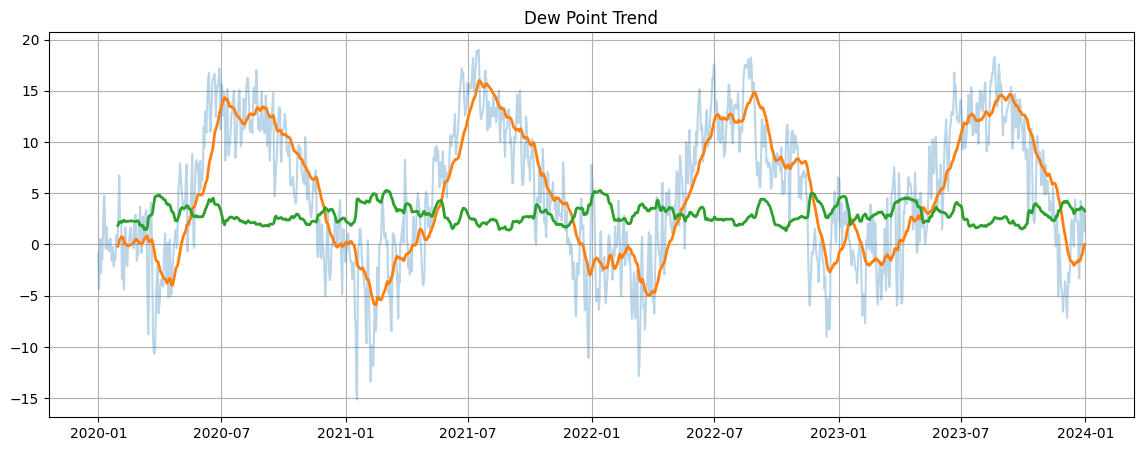

In [39]:
df["dewp_ma"] = df["dewp"].rolling(window=window).mean()
df["dewp_std"] = df["dewp"].rolling(window=window).std()

plt.figure(figsize=(14,5))

plt.plot(df.index, df["dewp"], alpha=0.3)
plt.plot(df.index, df["dewp_ma"], linewidth=2)
plt.plot(df.index, df["dewp_std"], linewidth=2)

plt.title("Dew Point Trend")
plt.grid()
plt.show()

1. 8. ROLNICTWO

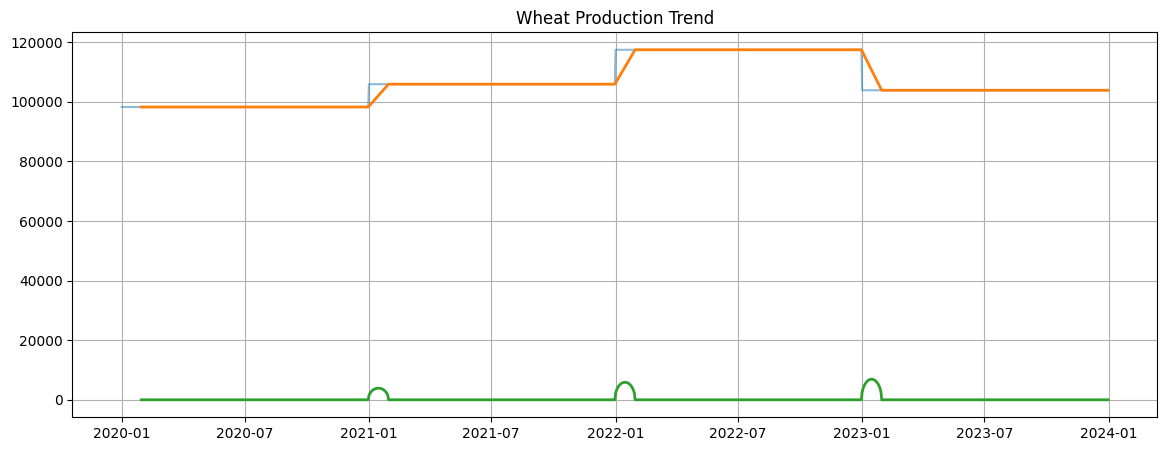

In [40]:
df["Wheat_ma"] = df["Tomatoes"].rolling(window=window).mean()
df["Wheat_std"] = df["Tomatoes"].rolling(window=window).std()

plt.figure(figsize=(14,5))

plt.plot(df.index, df["Tomatoes"], alpha=0.5)
plt.plot(df.index, df["Wheat_ma"], linewidth=2)
plt.plot(df.index, df["Wheat_std"], linewidth=2)

plt.title("Wheat Production Trend")
plt.grid()
plt.show()

In [41]:
exclude_cols = ['date','CTRY_ISO','temp', 'prcp', 'wdsp', 'slp', 'dewp']

agri_cols = [col for col in df.columns if col not in exclude_cols]

variation = df[agri_cols].std().sort_values(ascending=False)
variation

Chillies and peppers, green (Capsicum spp. and Pimenta spp.)    29857.785770
Cucumbers and gherkins                                           7659.589003
Tomatoes                                                         6991.944360
Wheat_ma                                                         6915.258369
Watermelons                                                      5403.084974
                                                                    ...     
Tung nuts                                                                NaN
Vanilla, raw                                                             NaN
Vetches                                                                  NaN
Yams                                                                     NaN
Yautia                                                                   NaN
Length: 169, dtype: float64

2. Część II

In [42]:
final = pd.read_csv("final.csv.gz")
final["date"] = pd.to_datetime(final["date"])

In [43]:
country = "PL"

df = final[final["CTRY_ISO"] == country].copy()
df = df.sort_values("date")

In [44]:
df["time"] = range(len(df))

In [45]:
split = int(len(df)*0.8)

train = df.iloc[:split]
test = df.iloc[split:]

In [46]:
def linear_regression_plot(column):

    X_train = train[["time"]]
    y_train = train[column]

    X_test = test[["time"]]
    y_test = test[column]

    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    plt.figure(figsize=(14,5))

    plt.plot(train["date"], y_train, label="Train")
    plt.plot(test["date"], y_test, label="Real Test")
    plt.plot(test["date"], predictions, label="Prediction", linewidth=3)

    plt.title(f"Linear Regression Prediction - {column}")
    plt.xlabel("Date")
    plt.ylabel(column)
    plt.legend()
    plt.grid()
    plt.show()

    print(column)
    print("R2:", round(r2_score(y_test, predictions),3))
    print("RMSE:", round(mean_squared_error(y_test, predictions)**0.5,3))

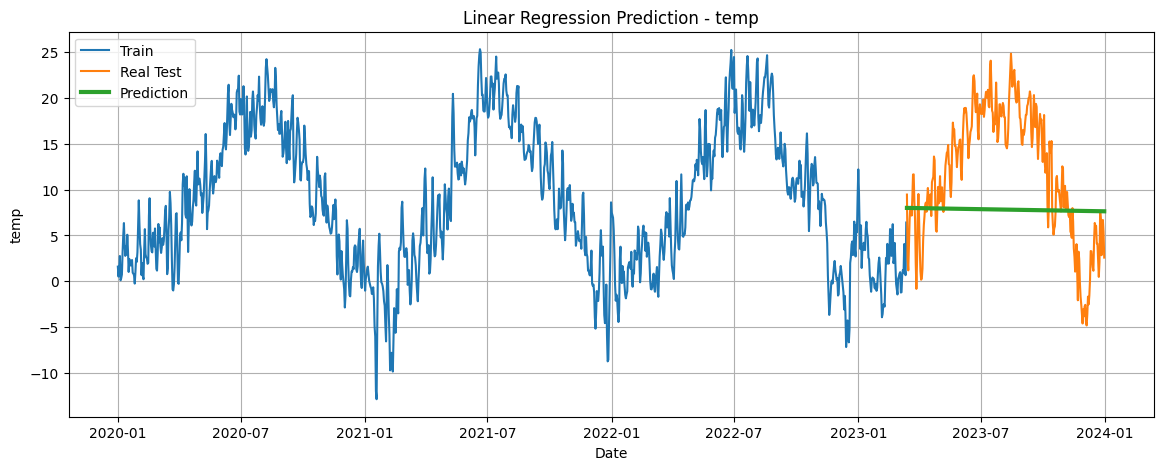

temp
R2: -0.321
RMSE: 8.015


In [47]:
linear_regression_plot("temp")

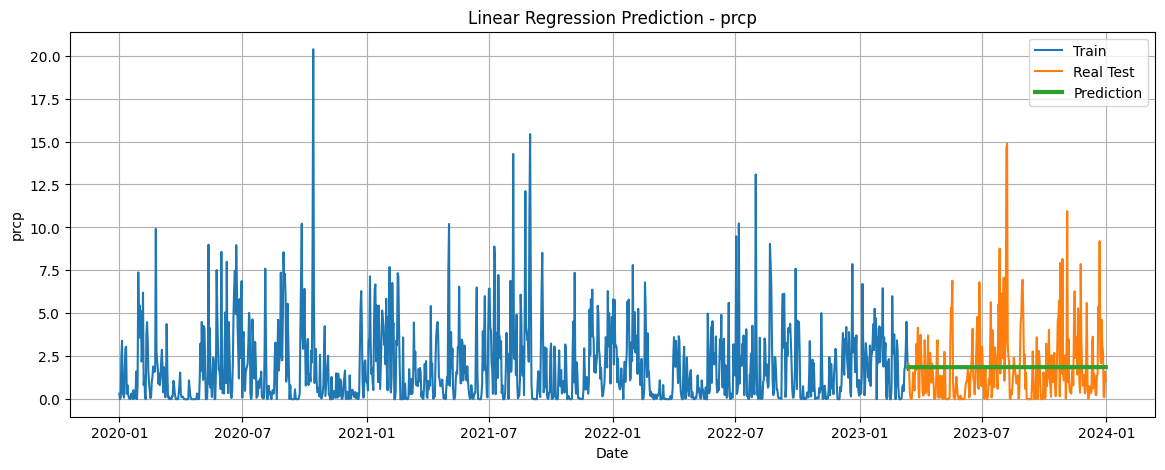

prcp
R2: 0.0
RMSE: 2.203


In [48]:
linear_regression_plot("prcp")

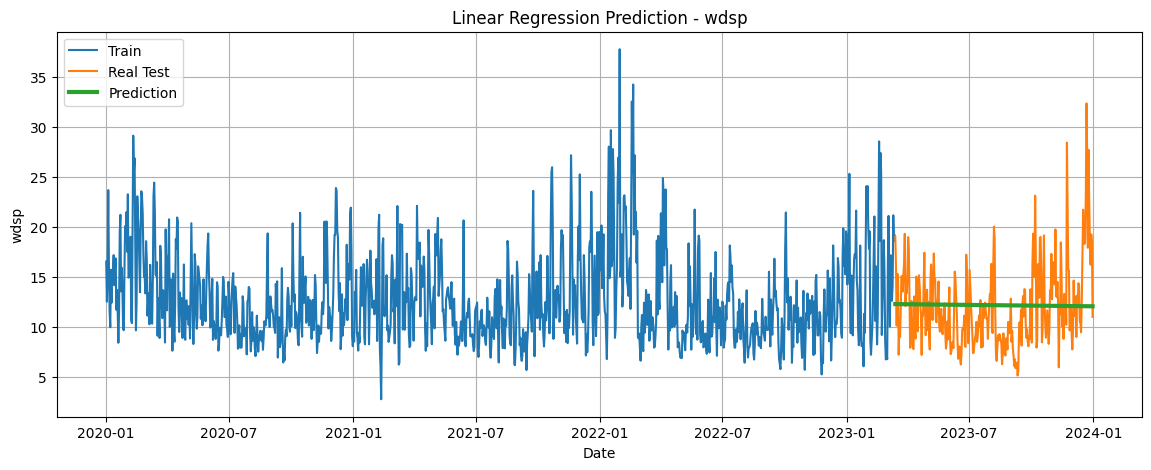

wdsp
R2: -0.008
RMSE: 4.17


In [49]:
linear_regression_plot("wdsp")

In [50]:
linear_regression_plot("slp")

ValueError: Input y contains NaN.

In [ ]:
linear_regression_plot("dewp")

In [ ]:
linear_regression_plot("Tomatoes")

In [ ]:
print(df.isna().sum())

CTRY_ISO          0
date              0
temp              0
prcp              0
wdsp              0
               ... 
Watermelons     366
Wheat             0
Yams           1461
Yautia         1461
time              0
Length: 165, dtype: int64
